In [1]:
import sys
sys.path.append('utils')
sys.path.append('models/ATPDrain_Etotfix')
sys.path.append('models')

from cobrak_main_workflows import run_cobrak_basic, remove_reaction
from analysis_functions import compute_total_enzyme_weight, compute_grouped_enzyme_mass, append_analysis_rows
from plotting_functions import plot_enzyme_analysis

from toy_model_full_Wcomp_wo_bio import initialize_model_w_comp
from toy_model_full_WOcomp_wo_bio import initialize_model_wo_comp

In [2]:
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime
import inspect

## dG0_transporter × Growth Rate

**Parameters:**
- Growth rates
- Transporter dG0
- 4 scenarios: comp+/comp- × ATP_con+/ATP_con-


In [3]:
import toy_params_yeast_weights_bioatp32_AllDefkm as extra_params

In [4]:
objective_target="ATP_Consumption"
objective_sense=1

#growth_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
#dG0_transport_values = [-10, -5, 0, 5, 10]

growth_grid = [0.1, 0.2, 0.4, 0.6]
dG0_transport_values = [-10, -5, 0, 5]


kcat = 1e20
pop_size = 128
evolution_num_gens = 60
uptake_tol = 0.1

total_runs = len(growth_grid) * len(dG0_transport_values) * 4
print(f"Total optimization runs: {total_runs}")
print(f"Growth rates: {growth_grid}")
print(f"Transporter dG0 values: {dG0_transport_values}")

Total optimization runs: 64
Growth rates: [0.1, 0.2, 0.4, 0.6]
Transporter dG0 values: [-10, -5, 0, 5]


In [5]:
sig = inspect.signature(initialize_model_w_comp)
valid_params = set(sig.parameters.keys())

sig_wo = inspect.signature(initialize_model_wo_comp)
valid_params_wo = set(sig_wo.parameters.keys())

### Scenario 1: With Compartment, without ATP constraint

In [6]:
results_grid1 = defaultdict(dict)

for dg0_val in dG0_transport_values:
    for growth_value in growth_grid:
        try:
            auto_kwargs = {
                name: getattr(extra_params, name)
                for name in dir(extra_params)
                if not name.startswith("_")
                and name in valid_params
            }
            auto_kwargs["k_cat_transport"] = kcat
            auto_kwargs["atp_concentration_constraint"] = False
            auto_kwargs["atp_m_concentration_constraint"] = False
            auto_kwargs["max_prot_pool"] = growth_value
            auto_kwargs["transport_dg0"] = dg0_val

            toy_model = initialize_model_w_comp(**auto_kwargs)
            remove_reaction(toy_model, "Overflow")

            print(f"[comp/noATP] growth={growth_value}, transport_dG0={dg0_val}")

            new_result = run_cobrak_basic(
                toy_model,
                objective_target=objective_target,
                objective_sense=objective_sense,
                variability_dict_fixed_params={},
                mode="evo",
                print_result=False,
                pop_size=pop_size,
                evolution_num_gens=evolution_num_gens,
            )
            results_grid1[growth_value][dg0_val] = new_result

        except Exception as e:
            print("ERROR!", e)

[comp/noATP] growth=0.1, transport_dG0=-10


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.5s remaining:    1.7s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.5s remaining:    0.8s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.6s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.7s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    4.0s
[Parallel(n_jobs=

[comp/noATP] growth=0.2, transport_dG0=-10


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.4s remaining:    1.3s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.4s remaining:    0.6s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.4s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.5s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    3.6s
[Parallel(n_jobs=

[comp/noATP] growth=0.4, transport_dG0=-10


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.013020038604736328s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.013600826263427734s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed

ERROR in initial sampling: No feasible sampling solution found! Check feasibility of problem and/or adjust sampling settings.
ERROR! 
[comp/noATP] growth=0.6, transport_dG0=5


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.006912708282470703s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.01407623291015625s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:

ERROR in initial sampling: No feasible sampling solution found! Check feasibility of problem and/or adjust sampling settings.
ERROR! 


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.014903068542480469s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.0143585205078125s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed: 

### Scenario 2: With Compartment, with ATP constraint

In [7]:
results_grid1_w_constraint = defaultdict(dict)

for dg0_val in dG0_transport_values:
    for growth_value in growth_grid:
        try:
            auto_kwargs = {
                name: getattr(extra_params, name)
                for name in dir(extra_params)
                if not name.startswith("_")
                and name in valid_params
            }
            auto_kwargs["k_cat_transport"] = kcat
            auto_kwargs["atp_concentration_constraint"] = True
            auto_kwargs["atp_m_concentration_constraint"] = True
            auto_kwargs["max_prot_pool"] = growth_value
            auto_kwargs["transport_dg0"] = dg0_val

            toy_model_w_constraint = initialize_model_w_comp(**auto_kwargs)
            remove_reaction(toy_model_w_constraint, "Overflow")

            print(f"[comp/ATP] growth={growth_value}, transport_dG0={dg0_val}")

            new_result = run_cobrak_basic(
                toy_model_w_constraint,
                objective_target=objective_target,
                objective_sense=objective_sense,
                variability_dict_fixed_params={},
                mode="evo",
                print_result=False,
                pop_size=pop_size,
                evolution_num_gens=evolution_num_gens,
            )
            results_grid1_w_constraint[growth_value][dg0_val] = new_result

        except Exception as e:
            print("ERROR!", e)

[comp/ATP] growth=0.1, transport_dG0=-10
ERROR: Rule failed when generating expression for Constraint
Extra_linear_constraint_0_LB with index None: ValueError: Invalid constraint
expression. The constraint expression resolved to a trivial Boolean (False)
instead of a Pyomo object. Please modify your rule to return
Constraint.Infeasible instead of False.

    Error thrown for Constraint 'Extra_linear_constraint_0_LB'
ERROR: Constructing component 'Extra_linear_constraint_0_LB' from data=None
failed:
        ValueError: Invalid constraint expression. The constraint expression
        resolved to a trivial Boolean (False) instead of a Pyomo object.
        Please modify your rule to return Constraint.Infeasible instead of
        False.

    Error thrown for Constraint 'Extra_linear_constraint_0_LB'
ERROR! Invalid constraint expression. The constraint expression resolved to a trivial Boolean (False) instead of a Pyomo object. Please modify your rule to return Constraint.Infeasible instead

### Scenario 3: Without Compartment, with ATP constraint

In [8]:
results_grid1_wo = defaultdict(dict)

for dg0_val in dG0_transport_values:
    for growth_value in growth_grid:
        try:
            auto_kwargs = {
                name: getattr(extra_params, name)
                for name in dir(extra_params)
                if not name.startswith("_")
                and name in valid_params_wo
            }
            auto_kwargs["atp_concentration_constraint"] = True
            auto_kwargs["max_prot_pool"] = growth_value
            auto_kwargs["transport_dg0"] = dg0_val

            toy_model_wo = initialize_model_wo_comp(**auto_kwargs)
            remove_reaction(toy_model_wo, "Overflow")


            print(f"[nocomp/ATP] growth={growth_value}, transport_dG0={dg0_val}")

            new_result = run_cobrak_basic(
                toy_model_wo,
                objective_target=objective_target,
                objective_sense=objective_sense,
                variability_dict_fixed_params={},
                mode="evo",
                print_result=False,
                pop_size=pop_size,
                evolution_num_gens=evolution_num_gens,
            )
            results_grid1_wo[growth_value][dg0_val] = new_result

        except Exception as e:
            print("ERROR!", e)

[nocomp/ATP] growth=0.1, transport_dG0=-10
ERROR: Rule failed when generating expression for Constraint
Extra_linear_constraint_0_LB with index None: ValueError: Invalid constraint
expression. The constraint expression resolved to a trivial Boolean (False)
instead of a Pyomo object. Please modify your rule to return
Constraint.Infeasible instead of False.

    Error thrown for Constraint 'Extra_linear_constraint_0_LB'
ERROR: Constructing component 'Extra_linear_constraint_0_LB' from data=None
failed:
        ValueError: Invalid constraint expression. The constraint expression
        resolved to a trivial Boolean (False) instead of a Pyomo object.
        Please modify your rule to return Constraint.Infeasible instead of
        False.

    Error thrown for Constraint 'Extra_linear_constraint_0_LB'
ERROR! Invalid constraint expression. The constraint expression resolved to a trivial Boolean (False) instead of a Pyomo object. Please modify your rule to return Constraint.Infeasible inste

### Scenario 4: Without Compartment, without ATP constraint

In [9]:
results_grid1_wo_wo_atpconstraint = defaultdict(dict)

for dg0_val in dG0_transport_values:
    for growth_value in growth_grid:
        try:
            auto_kwargs = {
                name: getattr(extra_params, name)
                for name in dir(extra_params)
                if not name.startswith("_")
                and name in valid_params_wo
            }
            auto_kwargs["atp_concentration_constraint"] = False
            auto_kwargs["max_prot_pool"] = growth_value
            auto_kwargs["transport_dg0"] = dg0_val

            toy_model_wo_wo_atpconstraint = initialize_model_wo_comp(**auto_kwargs)
            remove_reaction(toy_model_wo_wo_atpconstraint, "Overflow")


            print(f"[nocomp/noATP] growth={growth_value}, transport_dG0={dg0_val}")

            new_result = run_cobrak_basic(
                toy_model_wo_wo_atpconstraint,
                objective_target=objective_target,
                objective_sense=objective_sense,
                variability_dict_fixed_params={},
                mode="evo",
                print_result=False,
                pop_size=pop_size,
                evolution_num_gens=evolution_num_gens,
            )
            results_grid1_wo_wo_atpconstraint[growth_value][dg0_val] = new_result

        except Exception as e:
            print("ERROR!", e)

[nocomp/noATP] growth=0.1, transport_dG0=-10


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.3s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.3s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.3s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.3s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.2s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.2s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.2s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.3s remaining:    0.0s
[Pa

INFO: Fewer feasible sampling solutions found than wished.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done  89 tasks      | elapsed:    7.5s
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 118 out of 128 | elapsed:    9.1s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done 128 out of 128 | elapsed:    9.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_

[nocomp/noATP] growth=0.2, transport_dG0=-10


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done  89 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 118 out of 128 | elapsed:    9.2s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done 128 out of 128 | elapsed:    9.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_

[nocomp/noATP] growth=0.6, transport_dG0=5


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.4s remaining:    1.5s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.5s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.5s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.5s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    0.3s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    0.3s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.3s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    0.3s remaining:    0.0s
[Pa

INFO: Fewer feasible sampling solutions found than wished.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done  89 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 118 out of 128 | elapsed:    9.1s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done 128 out of 128 | elapsed:    9.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_

## Convert results to DataFrames

In [10]:
def flatten_results(results_dict, scenario_name, atp_scenario=None, compartment_scenario=None):
    """Convert nested defaultdict to flat list of dicts."""
    rows = []
    for growth_val, dg0_dict in results_dict.items():
        for dg0_val, result in dg0_dict.items():
            row = {
                'growth': float(growth_val),
                'transport_dG0': dg0_val,
                'scenario': scenario_name,
                'atp_scenario': atp_scenario,
                'compartment_scenario': compartment_scenario,
                'prot_pool_delivery': result.get('prot_pool_delivery', None),
                'Glycolysis_flux': result.get('Glycolysis', None),
                'Respiration_flux': result.get('Respiration', None),
                'Overflow_flux': result.get('Overflow', None),
                'ATP_Consumption': result.get('ATP_Consumption', None),
                'EX_S_flux': result.get('EX_S', None),
                'EX_C_flux': result.get('EX_C', None),
                'EX_P_flux': result.get('EX_P', None),
                'EX_B_flux': result.get('EX_B', None),
                'x_ATP': result.get('x_ATP', None),
                'x_ADP': result.get('x_ADP', None),
            }
            rows.append(row)
    return pd.DataFrame(rows)

df_comp = flatten_results(results_grid1, 'comp_noATP', atp_scenario="noConstraint", compartment_scenario="comp")
df_comp_atp = flatten_results(results_grid1_w_constraint, 'comp_ATP', atp_scenario="withConstraint", compartment_scenario="comp")
df_nocomp_atp = flatten_results(results_grid1_wo, 'nocomp_ATP', atp_scenario="withConstraint", compartment_scenario="nocomp")
df_nocomp = flatten_results(results_grid1_wo_wo_atpconstraint, 'nocomp_noATP', atp_scenario="noConstraint", compartment_scenario="nocomp")

df_all = pd.concat([df_comp, df_comp_atp, df_nocomp_atp, df_nocomp], ignore_index=True)

print(f"Total rows: {len(df_all)}")
print(f"Unique growth rates: {sorted(df_all['growth'].unique())}")
print(f"Unique dG0 values: {sorted(df_all['transport_dG0'].unique())}")
print(f"Scenarios: {df_all['scenario'].unique()}")
print()
print(df_all[['growth', 'transport_dG0', 'scenario', 'prot_pool_delivery']].to_string(index=False))

Total rows: 28
Unique growth rates: [np.float64(0.1), np.float64(0.2), np.float64(0.4), np.float64(0.6)]
Unique dG0 values: [np.int64(-10), np.int64(-5), np.int64(0), np.int64(5)]
Scenarios: ['comp_noATP' 'nocomp_noATP']

 growth  transport_dG0     scenario  prot_pool_delivery
    0.1            -10   comp_noATP            0.100000
    0.1             -5   comp_noATP            0.100000
    0.1              0   comp_noATP            0.100000
    0.2            -10   comp_noATP            0.200000
    0.2             -5   comp_noATP            0.200000
    0.2              0   comp_noATP            0.200000
    0.4            -10   comp_noATP            0.400000
    0.4             -5   comp_noATP            0.400000
    0.4              0   comp_noATP            0.400000
    0.6            -10   comp_noATP            0.600000
    0.6             -5   comp_noATP            0.600000
    0.6              0   comp_noATP            0.600000
    0.1            -10 nocomp_noATP            0.1

In [16]:
from compartment_comparison_plotting import *

In [17]:
len(df_all)

28

In [18]:
df_all

,growth,transport_dG0,scenario,atp_scenario,compartment_scenario,prot_pool_delivery,Glycolysis_flux,Respiration_flux,Overflow_flux,ATP_Consumption,EX_S_flux,EX_C_flux,EX_P_flux,EX_B_flux,x_ATP,x_ADP
0,0.1,-10,comp_noATP,noConstraint,comp,0.100000,10.769231,10.769231,None,64.615385,10.769231,10.769231,None,None,-5.928818,-6.043498
1,0.1,-5,comp_noATP,noConstraint,comp,0.100000,10.769231,10.769231,None,64.615385,10.769231,10.769231,None,None,-6.004772,-6.085610
2,0.1,0,comp_noATP,noConstraint,comp,0.100000,9.940866,9.940866,None,59.645195,9.940866,9.940866,None,None,-3.912889,-3.913292
3,0.2,-10,comp_noATP,noConstraint,comp,0.200000,21.538462,21.538462,None,129.230771,21.538462,21.538462,None,None,-5.938893,-6.053444
4,0.2,-5,comp_noATP,noConstraint,comp,0.200000,21.538462,21.538462,None,129.230771,21.538462,21.538462,None,None,-6.047252,-6.133875
5,0.2,0,comp_noATP,noConstraint,comp,0.200000,19.881730,19.881730,None,119.290379,19.881730,19.881730,None,None,-3.912583,-3.912987
6,0.4,-10,comp_noATP,noConstraint,comp,0.400000,43.076924,43.076924,None,258.461541,43.076924,43.076924,None,None,-5.975984,-6.089417
7,0.4,-5,comp_noATP,noConstraint,comp,0.400000,43.076924,43.076924,None,258.461541,43.076924,43.076924,None,None,-5.999224,-6.080048
8,0.4,0,comp_noATP,noConstraint,comp,0.400000,39.763458,39.763458,None,238.580747,39.763458,39.763458,None,None,-3.912486,-3.912890
9,0.6,-10,comp_noATP,noConstraint,comp,0.600000,64.615385,64.615385,None,387.692312,64.615385,64.615385,None,None,-6.027902,-6.154619


## Compute ATP consumption - compartment advantage

Best condition (max ATP advantage):


,growth,transport_dG0,atp_scenario,ATP_comp,ATP_nocomp,advantage
9,0.6,-10,noConstraint,387.692312,41.109794,346.582518


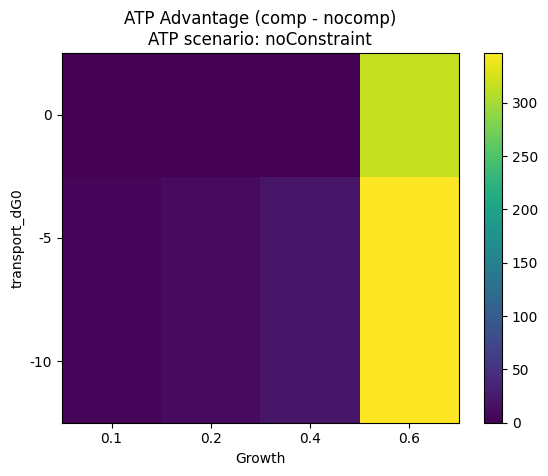

Scenario summary:


,atp_scenario,mean,min,max,count
0,noConstraint,89.94287,-0.03708,346.582518,12


,atp_scenario,mean,min,max,count
0,noConstraint,89.94287,-0.03708,346.582518,12


In [19]:
adv_df = compute_compartment_advantage(df_all)

# best condition
best_idx = adv_df["advantage"].idxmax()
best_row = adv_df.loc[best_idx]

best_table = pd.DataFrame([best_row[[
    "growth",
    "transport_dG0",
    "atp_scenario",
    "ATP_comp",
    "ATP_nocomp",
    "advantage"
]]])

print("Best condition (max ATP advantage):")
display(best_table)

#heatmaps
for scenario, sub in adv_df.groupby("atp_scenario"):

    pivot = sub.pivot_table(
        index="transport_dG0",
        columns="growth",
        values="advantage"
    )

    pivot = pivot.reindex(
        index=sorted(pivot.index),
        columns=sorted(pivot.columns)
    )

    plt.figure()
    plt.imshow(pivot.values, aspect="auto", origin="lower")

    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)

    plt.title(f"ATP Advantage (comp - nocomp)\nATP scenario: {scenario}")
    plt.xlabel("Growth")
    plt.ylabel("transport_dG0")
    plt.colorbar()
    plt.show()



summary = adv_df.groupby("atp_scenario")["advantage"].agg(
    ["mean", "min", "max", "count"]
).reset_index()

print("Scenario summary:")
display(summary)

summary

## Plotting

### ATP Consumption vs growth rate (by dG0)

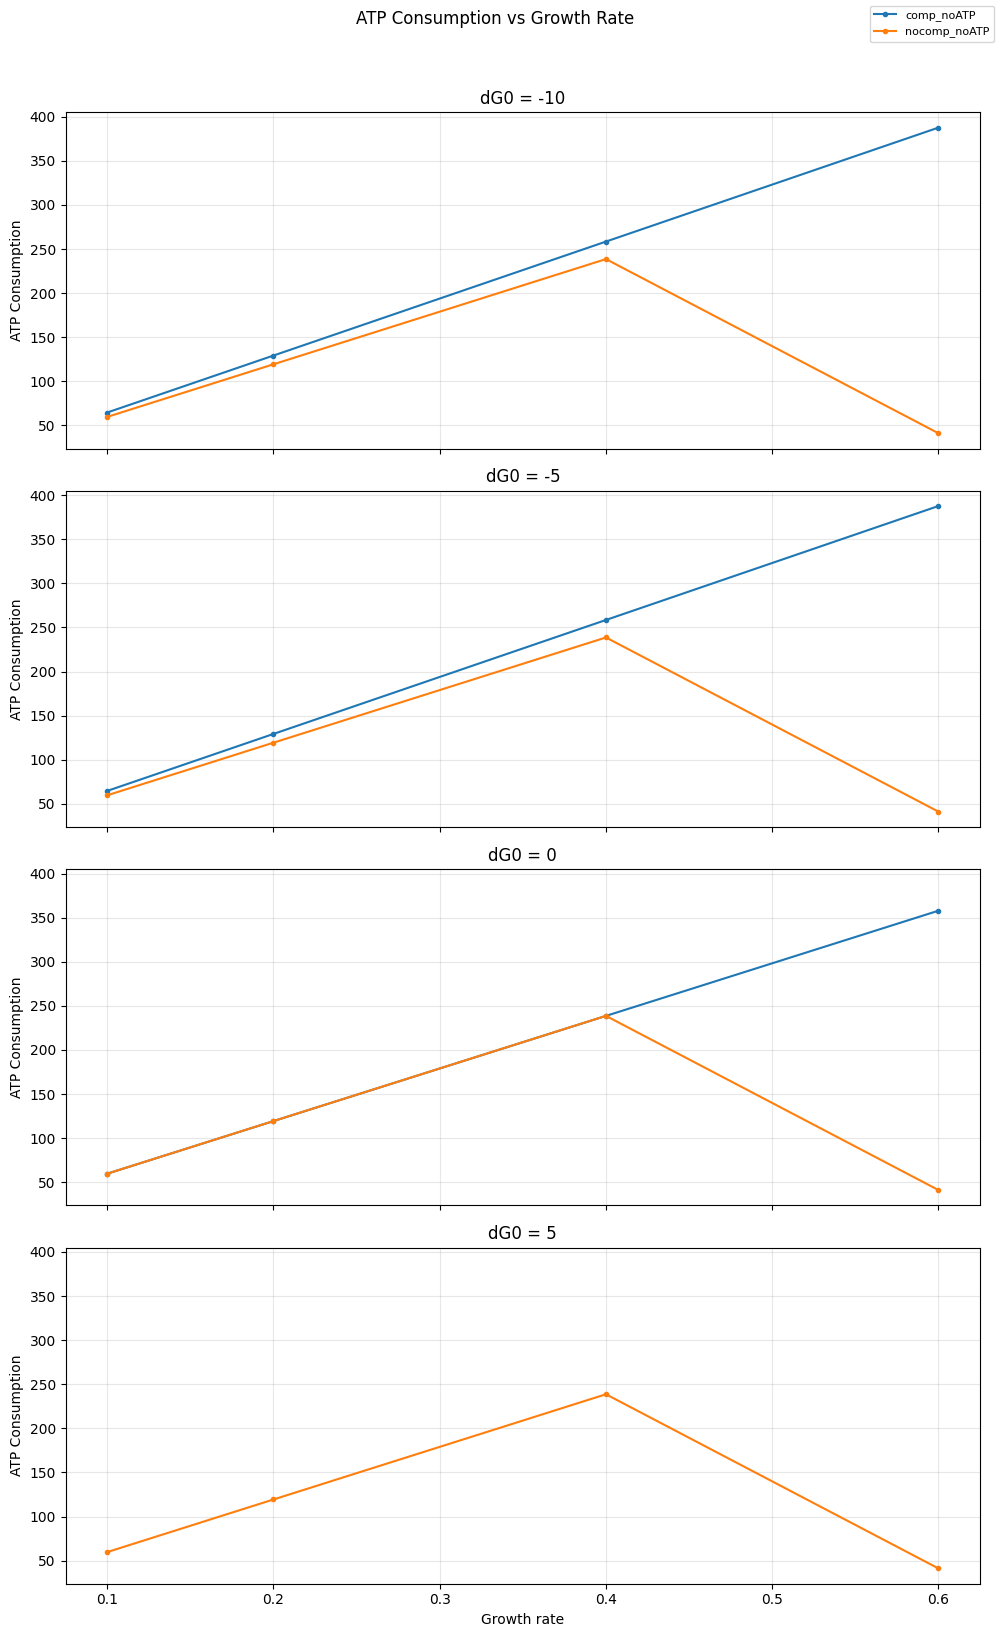

In [20]:
plot_cost_vs_growth_by_dg0(df_all)

### ATP Consumption avantage heatmap (growth × dG0), different visualization

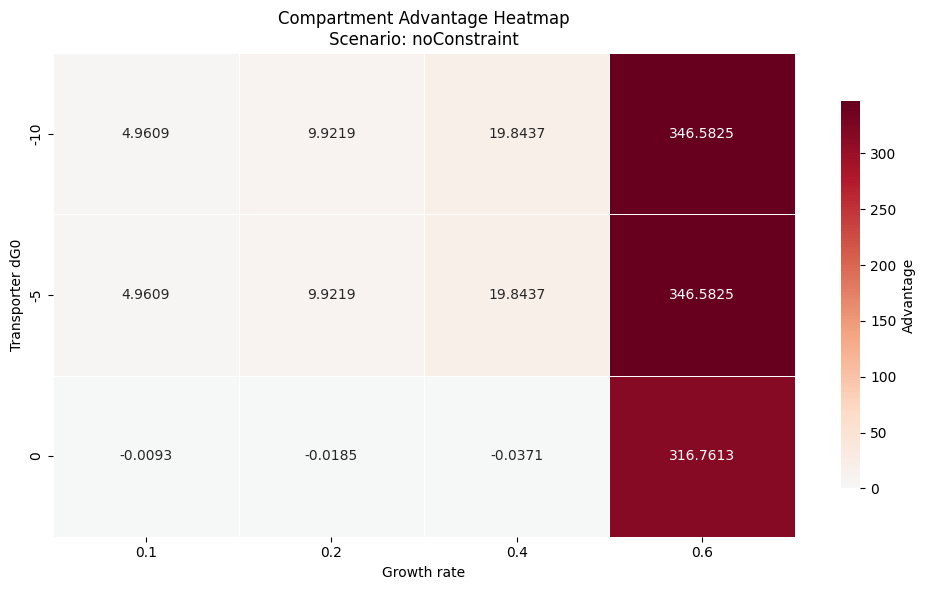

In [21]:
plot_advantage_heatmap(adv_df)

### ATP/ADP ratio vs growth rate (by dG0)

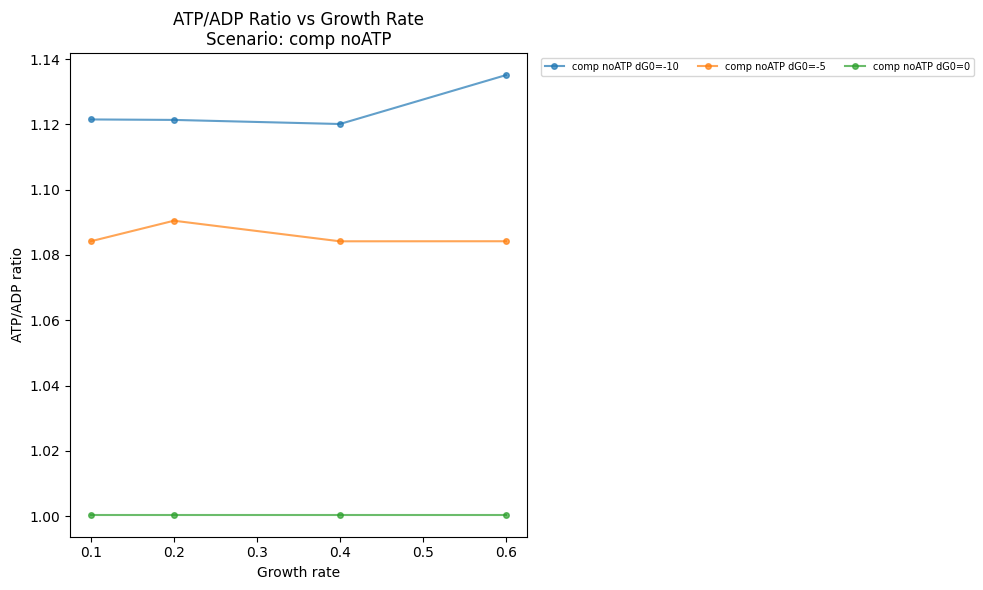

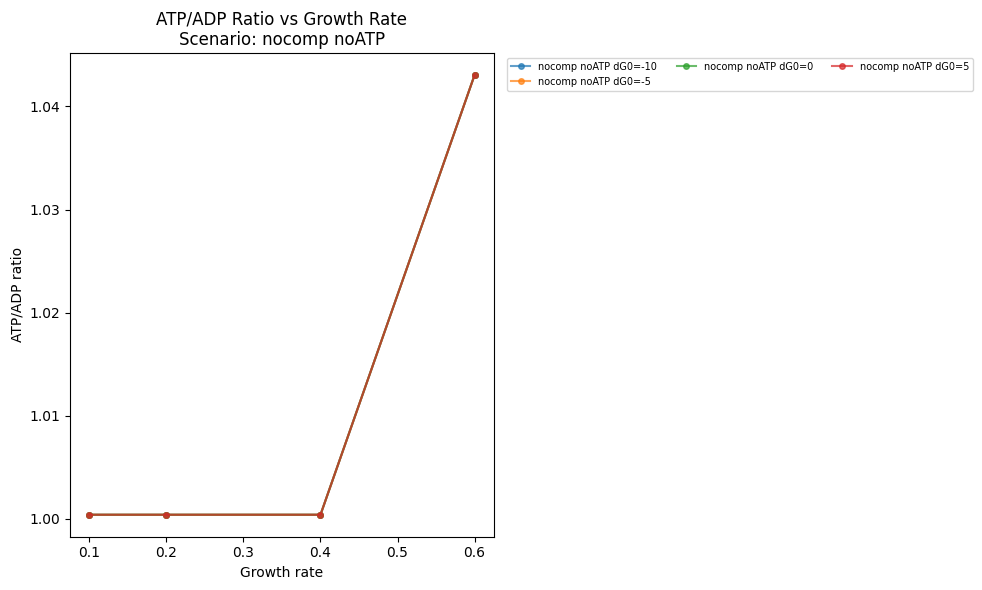

In [22]:
plot_atp_adp_ratio_vs_growth(df_all)

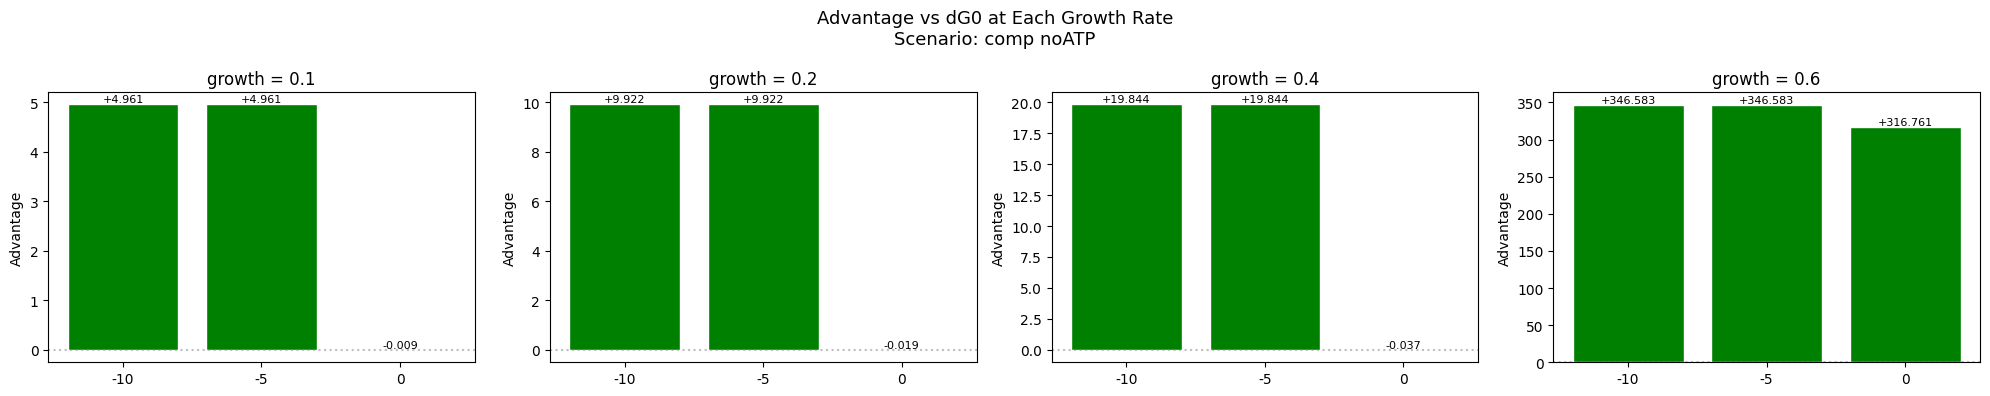

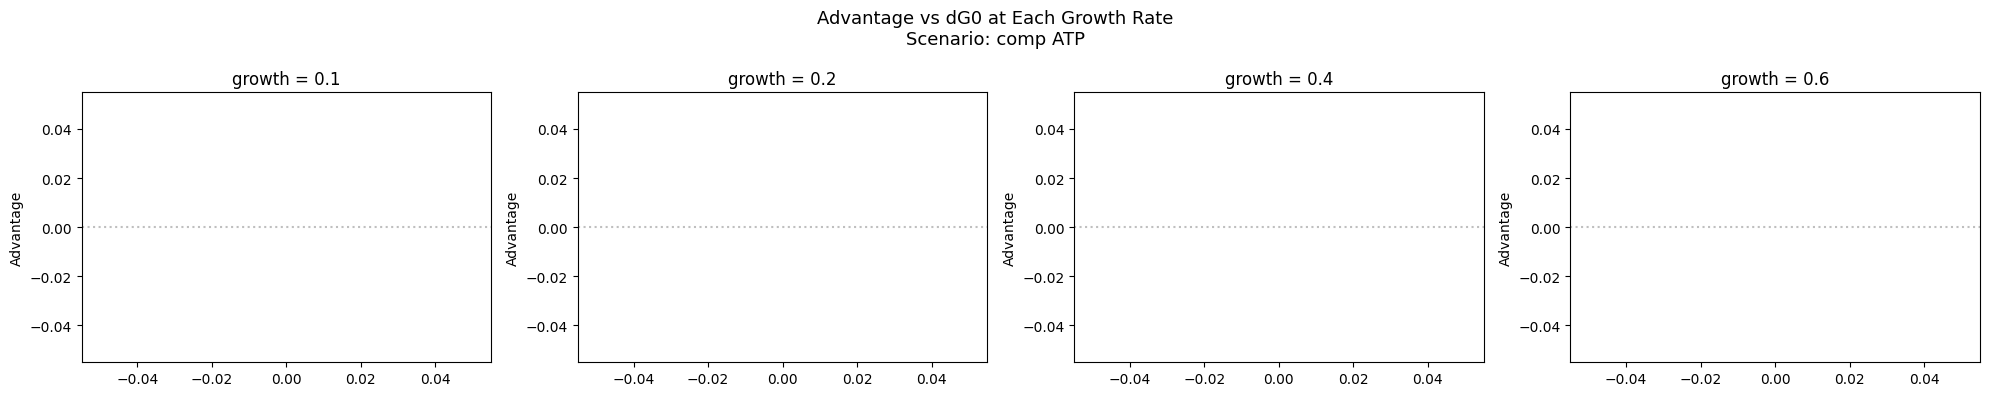

In [ ]:
plot_dg0_effect_by_growth(adv_df)

### Effect on fluxes (compartment with constraint)

In [24]:
df_for_plot = df_comp_atp.copy()
print("DataFrame for flux analysis (comp_ATP scenario):")
print(df_for_plot[['growth', 'transport_dG0', 'prot_pool_delivery',
                    'Glycolysis_flux', 'Respiration_flux', 'Overflow_flux']].to_string(index=False))

DataFrame for flux analysis (comp_ATP scenario):


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:3                                                                                    │
│                                                                                                  │
│   1 df_for_plot = df_comp_atp.copy()                                                             │
│   2 print("DataFrame for flux analysis (comp_ATP scenario):")                                    │
│ ❱ 3 print(df_for_plot[['growth', 'transport_dG0', 'prot_pool_delivery',                          │
│   4 │   │   │   │   │   'Glycolysis_flux', 'Respiration_flux', 'Overflow_flux']].to_string(i     │
│   5                                                                                              │
│                                                                                                  │
│ c:\Users\josef\.conda\envs\cobrak\lib\site-packages\pandas\core\frame.py:4119 in __getitem__     │
│                                                                                                  │
│    4116 │   │   else:                                                                            │
│    4117 │   │   │   if is_iterator(key):                                                         │
│    4118 │   │   │   │   key = list(key)                                                          │
│ ❱  4119 │   │   │   indexer = self.columns._get_indexer_strict(key, "columns")[1]                │
│    4120 │   │                                                                                    │
│    4121 │   │   # take() does not accept boolean indexers                                        │
│    4122 │   │   if getattr(indexer, "dtype", None) == bool:                                      │
│                                                                                                  │
│ c:\Users\josef\.conda\envs\cobrak\lib\site-packages\pandas\core\indexes\base.py:6212 in          │
│ _get_indexer_strict                                                                              │
│                                                                                                  │
│   6209 │   │   else:                                                                             │
│   6210 │   │   │   keyarr, indexer, new_indexer = self._reindex_non_unique(keyarr)               │
│   6211 │   │                                                                                     │
│ ❱ 6212 │   │   self._raise_if_missing(keyarr, indexer, axis_name)                                │
│   6213 │   │                                                                                     │
│   6214 │   │   keyarr = self.take(indexer)                                                       │
│   6215 │   │   if isinstance(key, Index):                                                        │
│                                                                                                  │
│ c:\Users\josef\.conda\envs\cobrak\lib\site-packages\pandas\core\indexes\base.py:6261 in          │
│ _raise_if_missing                                                                                │
│                                                                                                  │
│   6258 │   │                                                                                     │
│   6259 │   │   if nmissing:                                                                      │
│   6260 │   │   │   if nmissing == len(indexer):                                                  │
│ ❱ 6261 │   │   │   │   raise KeyError(f"None of [{key}] are in the [{axis_name}]")               │
│   6262 │   │   │                                                                                 │
│   6263 │   │   │   not_found = list(ensure_index(key)[missing_mask.nonzero()[0]].unique())       │
│   6264 │   │   │   raise KeyError(f"{not_found} not in inde

In [25]:
plot_enzyme_heatmaps(
    df_for_plot,
    variables=[
        "prot_pool_delivery",
        "Glycolysis_flux",
        "Respiration_flux",
        "Overflow_flux"
    ]
)

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱  1 plot_enzyme_heatmaps(                                                                       │
│    2 │   df_for_plot,                                                                            │
│    3 │   variables=[                                                                             │
│    4 │   │   "prot_pool_delivery",                                                               │
│                                                                                                  │
│ c:\Users\josef\Documents\GitHub\CobrakModels_ATPmax_drain\utils\compartment_comparison_plotting. │
│ py:175 in plot_enzyme_heatmaps                                                                   │
│                                                                                                  │
│   172 │                                                                                          │
│   173 │   for var in variables:                                                                  │
│   174 │   │                                                                                      │
│ ❱ 175 │   │   pivot = df.pivot_table(                                                            │
│   176 │   │   │   values=var,                                                                    │
│   177 │   │   │   index="transport_dG0",                                                         │
│   178 │   │   │   columns="growth",                                                              │
│                                                                                                  │
│ c:\Users\josef\.conda\envs\cobrak\lib\site-packages\pandas\core\frame.py:9536 in pivot_table     │
│                                                                                                  │
│    9533 │   ) -> DataFrame:                                                                      │
│    9534 │   │   from pandas.core.reshape.pivot import pivot_table                                │
│    9535 │   │                                                                                    │
│ ❱  9536 │   │   return pivot_table(                                                              │
│    9537 │   │   │   self,                                                                        │
│    9538 │   │   │   values=values,                                                               │
│    9539 │   │   │   index=index,                                                                 │
│                                                                                                  │
│ c:\Users\josef\.conda\envs\cobrak\lib\site-packages\pandas\core\reshape\pivot.py:102 in          │
│ pivot_table                                                                                      │
│                                                                                                  │
│    99 │   │   table = concat(pieces, keys=keys, axis=1)                                          │
│   100 │   │   return table.__finalize__(data, method="pivot_table")                              │
│   101 │                                                                                          │
│ ❱ 102 │   table = __internal_pivot_table(                                                        │
│   103 │   │   data,                                                                              │
│   104 │   │   values,                                                                            │
│   105 │   │   index,                                                                             │
│                                                            

In [26]:
plot_enzyme_lines(
    df_for_plot,
    variables=[
        "prot_pool_delivery",
        "Glycolysis_flux",
        "Respiration_flux",
        "Overflow_flux"
    ]
)

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱  1 plot_enzyme_lines(                                                                          │
│    2 │   df_for_plot,                                                                            │
│    3 │   variables=[                                                                             │
│    4 │   │   "prot_pool_delivery",                                                               │
│                                                                                                  │
│ c:\Users\josef\Documents\GitHub\CobrakModels_ATPmax_drain\utils\compartment_comparison_plotting. │
│ py:204 in plot_enzyme_lines                                                                      │
│                                                                                                  │
│   201 def plot_enzyme_lines(df, variables):                                                      │
│   202 │   df = df.copy()                                                                         │
│   203 │                                                                                          │
│ ❱ 204 │   dG0_values = sorted(df["transport_dG0"].unique())                                      │
│   205 │                                                                                          │
│   206 │   for var in variables:                                                                  │
│   207                                                                                            │
│                                                                                                  │
│ c:\Users\josef\.conda\envs\cobrak\lib\site-packages\pandas\core\frame.py:4113 in __getitem__     │
│                                                                                                  │
│    4110 │   │   if is_single_key:                                                                │
│    4111 │   │   │   if self.columns.nlevels > 1:                                                 │
│    4112 │   │   │   │   return self._getitem_multilevel(key)                                     │
│ ❱  4113 │   │   │   indexer = self.columns.get_loc(key)                                          │
│    4114 │   │   │   if is_integer(indexer):                                                      │
│    4115 │   │   │   │   indexer = [indexer]                                                      │
│    4116 │   │   else:                                                                            │
│                                                                                                  │
│ c:\Users\josef\.conda\envs\cobrak\lib\site-packages\pandas\core\indexes\range.py:417 in get_loc  │
│                                                                                                  │
│    414 │   │   │   except ValueError as err:                                                     │
│    415 │   │   │   │   raise KeyError(key) from err                                              │
│    416 │   │   if isinstance(key, Hashable):                                                     │
│ ❱  417 │   │   │   raise KeyError(key)                                                           │
│    418 │   │   self._check_indexing_error(key)                                                   │
│    419 │   │   raise KeyError(key)                                                               │
│    420                                                                                           │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
KeyError: 'transport_dG0'

## Save results to pickle

In [27]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

results_to_save = {
    'metadata': {
        'created': timestamp,
        'objective_target': objective_target,
        'objective_sense': objective_sense,
        'growth_grid': growth_grid,
        'dG0_transport_values': dG0_transport_values,
        'pop_size': pop_size,
        'evolution_num_gens': evolution_num_gens,
        'kcat': kcat,
        'total_runs': total_runs,
    },
    'all_results': {
        'comp_noATP': dict(results_grid1),
        'comp_ATP': dict(results_grid1_w_constraint),
        'nocomp_ATP': dict(results_grid1_wo),
        'nocomp_noATP': dict(results_grid1_wo_wo_atpconstraint),
    },
    'df_all': df_all,
    'advantage_df': adv_df,
}

pkl_path = f'dG0_growth_atp_consumption_wo_overflow_results_{timestamp}.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(results_to_save, f)
print(f"Saved results to: {pkl_path}")


Saved results to: dG0_growth_atp_consumption_wo_overflow_results_20260708_120322.pkl
